### Before You Begin

Please make a copy of this Python notebook into your Google Drive or onto your own computer. If you edit it directly without making a copy, your changes will be lost.

**IMPORTANT:** To assist our grading efforts, we have code and markdown cells with special annotations like these:

    # === STUDENT INPUT CELL: Exercise X ===
    <!-- === STUDENT INPUT CELL: Exercise Y === -->

You'll see these in the coding cells.  They are also in the reflection questions.  You can reveal them by double clicking on the text in the reflection question sections.

To avoid grading issues, we ask you to not remove or alter these. So please take extra precaution when you select-all and paste. Finally, only make changes in the cells with annotations. If you create additional cells during development, consolidate the final solution code and make sure your answer is in the notebook cell we are expecting.

Finally, before progressing with the exercise, make sure you run the following "SETUP CELL"s to initialize your notebook runtime environment.

In [ ]:
# SETUP CELL 1
!pip install sentence-transformers transformers umap-learn matplotlib numpy scikit-learn litellm qdrant-client -q

In [ ]:
# SETUP CELL 2
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# SETUP CELL
from sentence_transformers import SentenceTransformer

print("Loading Qwen3-Embedding-0.6B (this may take a minute on first run)...")
text_model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
print(f"Embedding dimension: {text_model.get_sentence_embedding_dimension()}")

# AI 5102 - Exercise 4: K-Nearest Neighbors and Retrieval Augmented Generation

In Exercise 3 (Semantic Search), we learned what embeddings are, how to compute distance/similarity with embeddings, how to extract embeddings from pre-trained models, how to visualize embeddings using dimensionality reduction techniques like UMAP,  solved SAT-style analogy problems, and reviewed applications of embeddings such as 1) semantic clustering, 2) detecting contextual meanings ("bank" example), 3) cross-lingual semantics, and 4) matching short and long texts, say a query and document. This exercise builds on Exercise 3 (Semantic Search), and now is a good time to review what you did there.


In this exercise, we will explore the [k-Nearest Neighbors](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm) algorithm for searching relevant results and technique known as [Retrieval Augmented Generation](https://proceedings.neurips.cc/paper/2020/hash/6b493230205f780e1bc26945df7481e5-Abstract.html) (RAG) which pairs an LLM with a search index to provide contextual results.

# Part I: K-Nearest Neighbors Retrieval

Now that we know how to turn text into vectors (points in an embedding space) and to compute distance/similarity between them, a natural question arises: **given a new piece of text, how do we find the most similar items in a large collection?**

This is the k-nearest neighbors (K-NN) problem — find the k items in a database that are most similar to a given query.

### Naive K-NN

The simplest approach: compute the similarity between the query and **every item** in the database, then return the top k.

This works, but it scales linearly — doubling the database doubles the search time. (As a forward pointer: in algorithms classes, you'll use *O(n)* as a shorthand to describe this runtime behavior.)

In [ ]:
def knn_search(query_vec, database_vecs, k=5):
    """Find the k most similar vectors using cosine similarity."""
    # Normalize all vectors so dot product = cosine similarity
    query_norm = query_vec / np.linalg.norm(query_vec)
    db_norms = database_vecs / np.linalg.norm(database_vecs, axis=1, keepdims=True)

    # Compute cosine similarities via dot product
    similarities = db_norms @ query_norm

    # Get top-k indices (highest similarity first)
    top_k_indices = np.argsort(similarities)[::-1][:k]

    return [(int(idx), float(similarities[idx])) for idx in top_k_indices]

Let's now try out this `knn_search` method product reviews to find a list of product reviews matching a search query. To do that, we will start with a handful of reviews and embed them using the same embedding model as used in Exercise 3, **Qwen3-Embedding-0.6B**.

In [ ]:
reviews = [
    "The battery lasts all day even with heavy use",
    "Screen is bright and colors are vivid",
    "Customer service was unhelpful and rude",
    "The keyboard feels great for typing long documents",
    "Battery drains too quickly when using GPS",
    "The display resolution is absolutely stunning",
    "Support team resolved my issue within minutes",
    "Keys are too small and feel cramped",
    "Charges fully in under an hour",
    "Touch screen is very responsive",
    "Had to wait 3 hours on hold for support",
    "The backlit keyboard is perfect for night work",
    "Battery performance degrades after a few months",
    "Picture quality on the monitor is cinema-grade",
    "The return process was smooth and hassle-free",
]

review_embeddings = text_model.encode(reviews)
print(f"Encoded {len(reviews)} reviews -> shape {review_embeddings.shape}")

Now, we can find all reviews related to, say, display quality. This is the essence of search (aka retrieval) using embeddings.

In [ ]:
import time

query = "display quality"
query_embedding = text_model.encode(query, prompt_name="query")

start_time = time.time()
results = knn_search(query_embedding, review_embeddings, k=3)
end_time = time.time()

print(f'Query: "{query}"')
print()
print("Top 3 results:")
print("-" * 65)
for rank, (idx, score) in enumerate(results, 1):
    print(f"  {rank}. [{score:.4f}] {reviews[idx]}")

print(f"\nTotal time for querying: {end_time - start_time}")

### Exercise 6.1: Naive Nearest Neighbors under the microscope

We will study this naive k-NN a bit deeply by scaling the inputs and seeing how it performs. Using the `reviews` array, construct three arrays `reviews_3x`, `reviews_5x`, and `reviews_10x` where each review is repeated 3, 5, and 10 times respectively. Embed each of these arrarys seperately, and search for the same term "display quality" using these 3 sets of embeddings and note the total time spent querying using each set. It took "0.291" miliseconds, for example, using the `reviews` array with 15 "documents" (length of the `reviews` array).



In [ ]:
# === STUDENT INPUT CELL: Exercise 6.1 ===
# Enter your response here


### Exercise 6.2 (reflection): Naive Nearest Neighbors under the microscope

1) Tabulate the number of "documents" (reviews) vs. the amount of time per query for the different datasets.

<!-- === STUDENT INPUT CELL: Exercise 6.2.1 === -->
**[TODO: Your input needed here]**

| Dataset | Size | Query Time (ms)|
|-------|-----------|------|
| `reviews` | 15 | 0.291 |
| `reviews_3x` | | |
| `reviews_5x` | | |
| `reviews_10x` | | |

2) Based on this table, how will this extrapolate to, say, a collection of 1M documents? Would that be acceptable for real-world use?

<!-- === STUDENT INPUT CELL: Exercise 6.2.2 === -->
**[TODO: Your input needed here]**

To assist handling massive document collections, [approximate nearest neigbhor](https://en.wikipedia.org/wiki/Nearest_neighbor_search#Approximate_nearest_neighbor) techniques are used. We will leave the discussion of such techniques to courses on advanced algorithms, but these techniques are readily available in commercial products like [Pinecone](https://www.pinecone.io/), [ChromaDB](https://www.trychroma.com/) and [Qdrant](https://qdrant.tech/), and open source softwares like [Annoy](https://github.com/spotify/annoy) and [FAISS](https://github.com/facebookresearch/faiss).

 # Part II: Retrieval Augmented Generation

rag_pipeline_d3_titlecase.svg

The Retrieval Augmented Generation (RAG) pipeline flows left to right through five stages. A user query enters the system in natural language and passes to the retriever, which searches and ranks passages from an external knowledge base of documents and vector embeddings. The retrieved context is then combined with the original query during the augmentation step, forming an enriched prompt. This augmented prompt is fed to the generator (an LLM!) which produces a final response grounded in the retrieved evidence rather than relying solely on its training data.

Usually, the 'knowledge base' is organized as a search index. This search index can be an index of the enitre web or a local index, which is typically used for private document collections. We will see a short demonstration of the former for completeness, but the focus of this exercise will be entirely on building RAG solutions for private documents.

> **Aside:**  *The 'knowledge base' in the product reviews example earlier was an array of embeddings.*

## Section 1: Retrieval Augmented Generation (RAG) with Web Search

Since implementing a web search index is not a feasible task for most, all LLM providers offer built in capabilities RAG with web search. They do via LLM tool calling (LLM tool calling in action — you saw this in the Function Calling session!) and details are provider-dependent. See, for example, documentation from [OpenAI](https://developers.openai.com/api/docs/guides/tools-web-search), [Anthropic](https://platform.claude.com/docs/en/agents-and-tools/tool-use/web-search-tool), and [Gemini](https://ai.google.dev/gemini-api/docs/google-search) on the matter.

> **Aside:** *When such search tools are used with modern reasoning models, like GPT-5.4 or Gemini-3.0-flash, it performs what's called an "Agentic RAG", where the LLM repeatedly invokes the search tool as many times as needed to answer the question. Designing Agentic RAG is not in scope for this exercise.*

The following code example, demonstrates this with OpenAI.

In [ ]:
# --- Portable secret loading -------------------------------------------------
# Works in Google Colab (Secrets panel, the key icon in the left sidebar),
# in VS Code / Jupyter (environment variable, e.g. loaded from a .env file),
# or interactively (prompt) as a last resort.
def get_secret(name: str) -> str:
    try:
        from google.colab import userdata          # Colab
        value = userdata.get(name)
        if value:
            return value
    except Exception:
        pass
    import os
    value = os.environ.get(name)                   # VS Code / Jupyter
    if value:
        return value
    from getpass import getpass                    # interactive fallback
    return getpass(f"Enter {name}: ")

In [ ]:
from openai import OpenAI
from rich import print as rprint
nvidia_api_key = get_secret("NVIDIA_API_KEY")

In [ ]:
client = OpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=nvidia_api_key
)

response = client.chat.completions.create(
    model="meta/llama-3.1-8b-instruct",
    messages=[
        {
            "role": "user",
            "content": "What are two positive news headlines from today? Only give me the news headlines, nothing else."
        }
    ]
)

rprint(response.choices[0].message.content)

### Exercise 6.3: Copy-paste the above code, modify it to NOT use web search, and rerun using the same prompt.

In [ ]:
# === STUDENT INPUT CELL: Exercise 6.3 ===
# Enter your response here

### Exercise 6.4 (Reflection): Need for search grounding

As we see from exercise 6.4, one reason to *ground* an LLM with search tools is to give them access to up-to-date information to answer the user query. Can you think of another reason or situation where search-based grounding is indispensible with LLMs?

**[TODO: Enter your response here]**

## Section 2: Retrieval Augmented Generation (RAG) with a proprietary knowledge base

For this part of the exercise, we will use a commercial nearest neighbor search engine called Qdrant. Since Qdrant works with OpenAI embeddings, we will also switch our embedder to the OpenAI embedding model. For this section, we will look into answering questions about NVIDIA's earnings calls.


Let's say we wanted to know "What were NVIDIA's quarterly earnings in Q1 2025?". We could consider making an LLM API call.

In [ ]:
from litellm import completion
import os

os.environ["NVIDIA_API_KEY"] = get_secret("NVIDIA_API_KEY")

nvidia_api_key = get_secret("NVIDIA_API_KEY")

messages = [
    {
        "role": "user",
        "content": "What were NVIDIA's quarterly earnings in Q1 2025?"
    }
]

response = completion(
    model="nvidia_nim/meta/llama-3.1-8b-instruct",
    messages=messages,
    api_key=nvidia_api_key
)

print(response.choices[0].message.content)



GPT-4o is incredibly smart, but it has a **big limitation**—it only knows what it was trained on.

**The Solution?**  

Instead of relying on GPT-4o's *limited knowledge*, what if we **feed it** the actual financial reports and let it retrieve accurate answers?  

## Document Processing and Embeddings (10 points)

In this section, you will prepare a financial document for retrieval.

Instead of relying on an AI model’s memory, we will:
1. convert document text into chunks
2. generate embeddings for each chunk
3. prepare these embeddings for similarity-based retrieval

For this task, we will use a [9-page PDF document](https://nvidianews.nvidia.com/_gallery/download_pdf/664e53fe3d63322459a5eff6/) that has NVIDIA's financial results for Q1 2025. Since most LLMs natively work with text, we will need to convert the PDF to text. Typically, you would do that using an external library or service, such as [Marker](https://pypi.org/project/marker-pdf/), [PyMuPDF](https://pymupdf.readthedocs.io/en/latest/), etc. Since this is tangential to the homework, we have a processed version of the PDF in Markdown format at this [link](https://gist.github.com/delip/4ef79493215bd89c88f29cdcfa37cb9f).

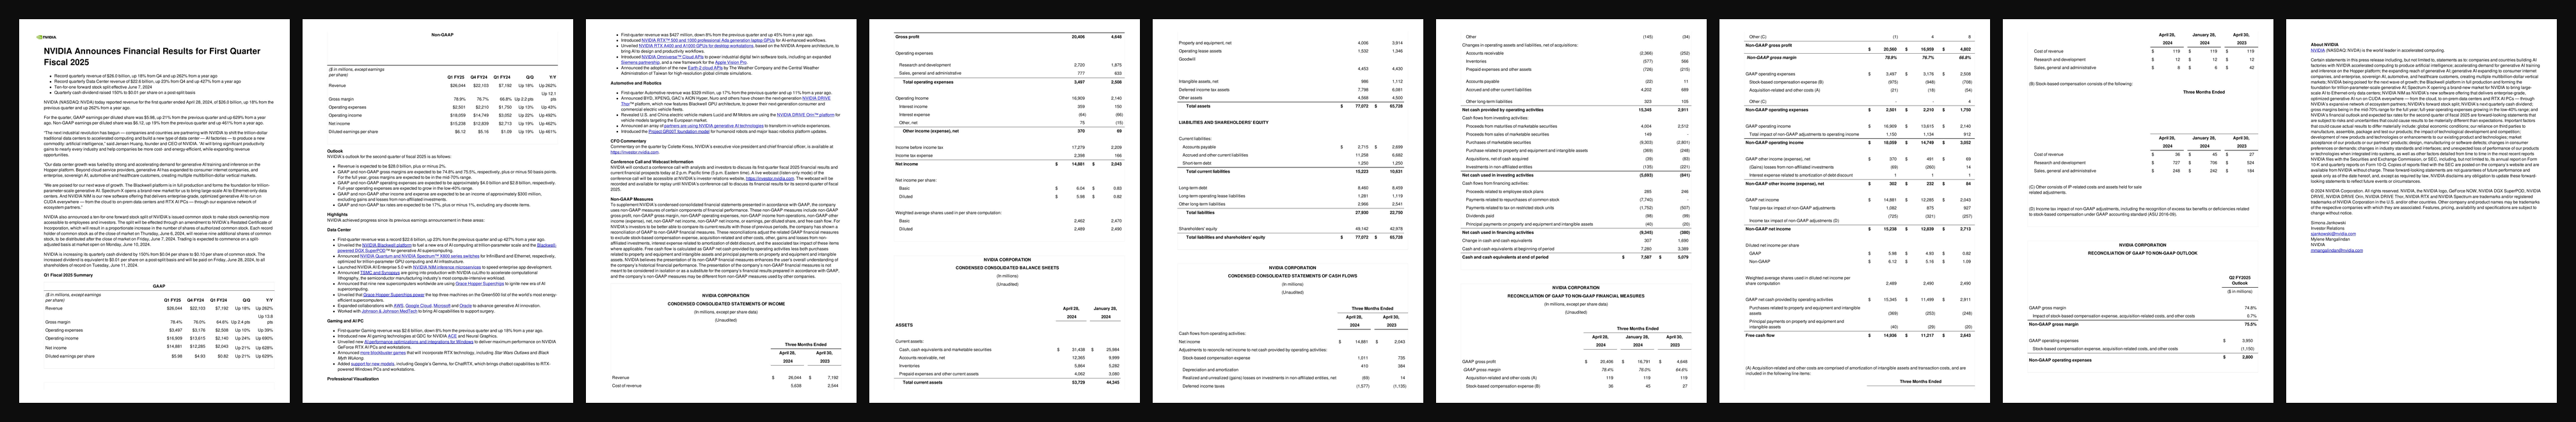

In [ ]:
import requests

# Use the ID from the upload step or an existing Gist ID
GIST_ID = '4ef79493215bd89c88f29cdcfa37cb9f'

# 1. Get Gist Metadata
gist_url = f"https://api.github.com/gists/{GIST_ID}"
response = requests.get(gist_url)

if response.status_code == 200:
    gist_data = response.json()

    # 2. Extract Raw URL for the first file
    first_file_key = list(gist_data['files'].keys())[0]
    raw_url = gist_data['files'][first_file_key]['raw_url']

    # 3. Download the actual content as a string
    file_content_response = requests.get(raw_url)
    pdf_text = file_content_response.text

    print("Downloaded Content:")
    rprint(pdf_text[:1000])
else:
    print(f"Failed to fetch gist: {response.status_code}")

## Extract and Chunk Text

LLMs cannot embed extremely large documents at once.

Instead, we split the report into smaller pieces called **chunks**.

Each chunk becomes a searchable memory entry.

In [ ]:
#  Split the extracted text into chunks for better processing. For example, we split by every 500 characters (you can adjust this as needed).
def split_text(text, chunk_size=500):
    return [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]

text_chunks = split_text(pdf_text, chunk_size=500)
print(f"Split text into {len(text_chunks)} chunks.")

### Exercise 6.5 (Reflection)

<!-- === STUDENT INPUT CELL: Exercise 2A === -->

In 2 to 3 sentences:

1. Why is chunking necessary for RAG systems?

2. What problem would occur if we embedded the entire report as a single vector?

**Your Answers:**

1. **[TODO: Your input needed here]**

2. **[TODO: Your input needed here]**



Qdrant requires OpenAI embeddings. Let's write a helper function to generate these embeddings.

In [ ]:
# Complete the get_embedding function
from litellm import embedding

def get_embedding(text, model, dimensions=1536):
    response = embedding(
        model=model,
        input=[text],
        dimensions=dimensions
    )
    return response.data[0]['embedding']

Now, we can embed our text chunks.

In [ ]:
embeddings = []

for chunk in text_chunks:
    response = embedding(
        model="nvidia_nim/nvidia/nemotron-3-embed-1b",
        input=[chunk],
        api_key=nvidia_api_key
    )

    embeddings.append(response.data[0]["embedding"])

print(f"Successfully generated {len(embeddings)} embeddings!")
print("Embedding dimension:", len(embeddings[0]))


Qdrant is a Vector Database that helps store and retrieve high-dimensional data efficiently. Think of it like a smart search engine that understands meaning, not just keywords!

**Why Use Qdrant?**

Stores embeddings - AI models like GPT turn text into numerical representations (vectors), and Qdrant stores them for easy retrieval.

Fast & Scalable - Handles millions of vectors quickly, making it great for large datasets.

Perfect for RAG - Helps retrieve the most relevant data for Retrieval-Augmented Generation (RAG) models.

**How Does It Work?**
Convert financial text into vector embeddings using an AI model (which we did above).
Store these embeddings in Qdrant.
When you ask a question, Qdrant retrieves the most relevant vectors. This is much like our k-NN example, except we will use it to improve responses from the LLM.


In [ ]:
from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance

# Set up Qdrant API key and URL
QDRANT_API_KEY = get_secret("QDRANT_API_KEY")
QDRANT_URL = get_secret("QDRANT_URL")


Refer to the [Qdrant Documentation](https://python-client.qdrant.tech/) if you get stuck.

In [ ]:
# Initialize a Qdrant client to interact with our Vector DB

qdrant_client = QdrantClient(
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY,
)

print(qdrant_client.get_collections())

In [ ]:
# Here we create a collection that will be used to store our embeddings. A **collection** is similar to a table in a traditional database — it is where we store vectors.

collection_name = "new" ## change name accordingly if you are running the session once and want to create a new
vector_size = 2048

# Check if collection exists before creating
if not qdrant_client.collection_exists(collection_name):
    try:
        qdrant_client.create_collection(
            collection_name=collection_name,
            vectors_config=VectorParams(
                size=vector_size,
                distance=Distance.COSINE
            )
        )
        print(f"Collection '{collection_name}' created successfully!")
    except Exception as e:
        print(f"Error creating collection: {e}")
else:
    print(f"Collection '{collection_name}' already exists.")


### Preparing Data for Storage

A vector database does not just store numbers.

Each vector must also include:
- a unique ID
- the vector
- metadata (payload)

We will store the original text chunk as metadata so we can retrieve it later.

In [ ]:
# Prepare data points for Qdrant upsert
points = []
for idx, (chunk, emb) in enumerate(zip(text_chunks, embeddings)):
    point = {
        "id": idx,  # Unique ID for each chunk
        "vector": emb,  # The generated embedding vector
        "payload": {
            "text": chunk  # Store the text chunk in the payload for retrieval
        }
    }
    points.append(point)

print(f"Prepared {len(points)} data points for Qdrant upsert.")

### Exercise 6.6: Complete the Upsert Code

We will now store the document into Qdrant. This is the moment the AI gains external knowledge.

Your task: **Complete the upsert function to push points into the Qdrant collection.**  

- Use the correct **collection name** from your setup.  
- Ensure `points` contains the **vector embeddings** from the PDF text.  
- Call `qdrant_client.upsert()` properly to store the data.  

Look [here](https://qdrant.tech/documentation/concepts/points/) for reference and fill in the missing details below:



In [ ]:
# === STUDENT INPUT CELL: Exercise 6.6 ===
# TODO: Upsert (store) the chunk embeddings into Qdrant.
# Requirements:
# - Use the provided `collection_name`
# - Use `text_chunks`
# - Store each chunk in the payload under key "text"
# - Use incremental integer IDs


# Upsert the points into your Qdrant collection #(Make sure you've already set up your Qdrant client and created the collection as in previous steps)

qdrant_client.upsert(
    # collection_name="new",  # Use the collection name you created earlier
    # points=points
)

print("All text chunks from the PDF have been upserted into Qdrant successfully!")

### Exercise 6.7: Implement Search

Your task: **Complete the `search_qdrant` function to retrieve relevant results from Qdrant.**  

- Use the correct **collection name** from your setup.  
- Ensure `query_embedding` is properly passed for searching.  
- Return the retrieved **text chunks** as a single concatenated string.  

Look [here](https://qdrant.tech/documentation/concepts/search/) for reference.


In [ ]:
# === STUDENT INPUT CELL: Exercise 6.7 ===

## Complete search function
def search_qdrant(query_embedding, collection_name, limit=3):
    """Search Qdrant and return concatenated context"""
    # try:
    #     results = qdrant_client.search(
    #         collection_name=collection_name,
    #         query_vector=query_embedding,
    #         limit=limit
    #     )
    #     return "\n".join([result.payload["text"] for result in results])
    # except Exception as e:
    #     print(f"Search error: {e}")
    #     return ""

### Example of RAG in Action: Retrieving and Answering a Financial Query

In [ ]:
user_question = "What are the key drivers behind NVIDIA's record revenue growth this quarter?"
try:
    query_embedding = get_embedding(
        text=user_question,
        model="text-embedding-3-small",
        dimensions=1536
    )
except Exception as e:
    print(f"Embedding error: {e}")
    query_embedding = []

context = search_qdrant(query_embedding, collection_name)

prompt = f"""You are a financial expert. Analyze this NVIDIA Q1 2025 report extract:
{context}

Question: {user_question}
Answer concisely with numerical figures where available:"""

try:
    response = completion(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": "You are a helpful financial analysis assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.2,
        num_retries=2  # LiteLLM reliability feature
    )
    answer = response.choices[0].message.content
except Exception as e:
    answer = f"Error generating response: {e}"

print("User Query:", user_question)
print("\nAnswer:\n", answer)

The cell above performed a full Retrieval-Augmented Generation (RAG) pass:

1. **Embed the question**: convert the user question into a vector.
2. **Retrieve context**: use Qdrant to find the most similar document chunks.
3. **Prompt the model**: pass retrieved text + the user question to GPT-4o.
4. **Generate an answer grounded in the report.**

**Key idea:** The answer quality depends heavily on the *retrieved context*. If retrieval is wrong, the model may answer incorrectly even if it is powerful.

### Exercise 6.8 (Reflection)

You have now seen RAG answer a financial question using retrieved context from your uploaded report.

<!-- === STUDENT INPUT CELL: Exercise 6.8 === -->

Answer briefly (4 -- 8 sentences total):

1. **Retrieval check:** Did the retrieved `context` actually contain relevant evidence for the question? (Yes/No + 1 sentence)
2. **Evidence quote:** Copy **one short phrase or number** from the retrieved context that supports the answer.
3. **Grounding:** Why is this approach more reliable than asking the model without retrieval?
4. **Failure mode:** Give one concrete reason the answer could still be wrong even with RAG.

**Your Answers:**

1.

2.

3.

4.

# Part III: Build Your Interactive Chatbot

Your mission is to create a chatbot that will:
- Use Qdrant's search functionality to retrieve relevant text chunks from our financial documents.
- Leverage GPT-4o’s prompting skills to answer the business questions we discussed.
- Convert the user’s question into an embedding and use the search function to retrieve relevant context.
- Then build a prompt using the retrieved context and the user’s question, and ask GPT-4o to answer based only on that information.
- Continuously interact with the user until the command `"exit"` is specified.


**Business Questions to Answer Using RAG**

Your chatbot should be able to assist in answering the following **10 business-critical questions**:

1. What are the key drivers behind NVIDIA's record revenue growth this quarter?  
2. How do the quarter-over-quarter and year-over-year figures compare, and what insights do they offer?  
3. In what ways does the growth in Data Center revenue impact overall company performance?  
4. How does the company's strategy in leveraging generative AI reflect in its financial results?  
5. What are the main differences between GAAP and non-GAAP measures, and why do they matter?  
6. How do operating expenses and margins reveal the company's efficiency in managing costs?  
7. What insights can be drawn from NVIDIA's outlook for the next quarter?  
8. How do strategic moves like stock splits and dividend increases influence investor confidence?  
9. What potential risks can you identify from the financial data, and how might they be mitigated?  
10. How do partnerships and technological advancements contribute to the company's long-term growth strategy?  

### Exercise 6.9

Build a loop that answers questions using rag_answer() until user types "exit".

In [ ]:
# === STUDENT INPUT CELL: Exercise 6.9 ===
# Build a loop that answers questions using RAG until the user types "exit".
#
# You MUST implement:
#   1) rag_answer(question, collection_name, limit=3)
#   2) chatbot(collection_name)
#
# You may assume these already exist from earlier parts:
#   - get_embedding(text, model, dimensions)
#   - search_qdrant(query_embedding, collection_name, limit)
#   - completion(...) from litellm

def rag_answer(question, collection_name, limit=3):
    """
    TODO:
    - Create an embedding for `question` using get_embedding(...)
    - Retrieve relevant context using search_qdrant(...)
    - Build a prompt that includes the retrieved context + the question
    - Call completion(model="gpt-4o", ...) and return the assistant's text answer
    - If retrieval returns empty context, return a helpful message
    """
    # 1) Embed the question
    # query_embedding = ...

    # 2) Retrieve context
    # context = ...

    # 3) Build prompt (use ONLY context)
    # prompt = f""" ... """

    # 4) Call GPT-4o
    # resp = completion(...)
    # return ...



def chatbot(collection_name):
    """
    TODO:
    - Repeatedly ask the user for a question
    - If user types "exit", stop
    - Otherwise print rag_answer(question, collection_name)
    """


# Uncomment to run:
# chatbot(collection_name)

### Exercise 6.10

 Answer the 10 business questions by setting variables exactly as required using your chatbot above.

In [ ]:
# === STUDENT INPUT CELL: Exercise 6.10 ===
# Business questions: fill these using the value returned by rag_answer(...)
Q1_answer = ""
Q2_answer = ""
Q3_answer = ""
Q4_answer = ""
Q5_answer = ""
Q6_answer = ""
Q7_answer = ""
Q8_answer = ""
Q9_answer = ""
Q10_answer = ""

## Evaluating and Grounding Your RAG System

The sections above gave you a complete RAG pipeline: chunk a document, embed the chunks, store them in Qdrant, retrieve the most relevant ones for a question, and ask an LLM to answer using that context.

Two things are still missing from a *trustworthy* RAG system:

1. **Citations.** A user reading an answer has no way to check which retrieved passage backs which claim. We'll extend the answer step so the model cites chunk numbers inline (e.g. `[1]`, `[2]`), and we'll return the cited chunks alongside the answer.
2. **Evaluation.** More context (bigger `chunk_size`, higher `limit`/k) isn't automatically better — bigger chunks dilute relevance, and too many retrieved passages can bury the model in irrelevant text. We'll build a small ablation harness that varies `chunk_size` and `k` and reports how retrieval and answers change, plus a lightweight "faithfulness" check that flags answer claims not actually supported by the retrieved chunks.

To make these pieces testable without any API key, Qdrant instance, or network access, we factor the **pure logic** (chunking, citation-tag parsing, cosine top-k selection, faithfulness-verdict parsing) into standalone functions that take plain Python/NumPy inputs and a plug-in `llm_fn` (or `embed_fn`) callable. In production cells we pass the real `completion`/`get_embedding` functions; in tests we pass fakes. This mirrors how you'd design these functions in a real codebase so they can be unit tested in CI without live API calls.

### 1. Source Citations

`rag_answer` (Exercise 6.9) returns only a text string, so there's no way to trace a claim back to a specific chunk. Below we add an **augmented** version, `rag_answer_with_citations`, that:

- Numbers the retrieved chunks `[1]`, `[2]`, `[3]`, ... in the prompt,
- Instructs the LLM to cite chunk numbers inline next to any claim it draws from them,
- Returns a dict with the answer text, the cited chunk numbers (parsed out of the answer), and the full retrieved chunks (id + text) — so a UI could show "sources" alongside the answer.

The original `rag_answer` from Exercise 6.9 is left untouched; this is a separate, additive function. `extract_citations` (the regex-based parser) and `build_cited_context` (the numbering logic) are pure functions with no API calls, so they're unit tested directly in `tests/test_a4.py`.

In [ ]:
# === Source citations for RAG answers ===
import re


def build_cited_context(chunks):
    """Number a list of retrieved chunks for citation and build the context string.

    Args:
        chunks: list of dicts like {"id": <int>, "text": <str>}, in retrieval
                rank order (best match first). This is the same shape you'd get
                back from `search_qdrant` if it returned structured hits instead
                of a single concatenated string.

    Returns:
        (context_str, numbered_chunks) where:
          - context_str has each chunk prefixed with "[n] " for n = 1..len(chunks)
          - numbered_chunks is [{"citation_id": n, "id": chunk_id, "text": text}, ...]
    """
    numbered_chunks = []
    lines = []
    for n, chunk in enumerate(chunks, start=1):
        numbered_chunks.append({
            "citation_id": n,
            "id": chunk["id"],
            "text": chunk["text"],
        })
        lines.append(f"[{n}] {chunk['text']}")
    context_str = "\n".join(lines)
    return context_str, numbered_chunks


def extract_citations(answer_text, numbered_chunks):
    """Parse inline citation markers like [1] or [2] out of an LLM answer.

    Args:
        answer_text: the LLM's answer, expected to contain markers such as
                      "...grew 30% [1] due to demand [2]..."
        numbered_chunks: the list returned by `build_cited_context`, used to
                          map citation numbers back to original chunk ids/text.

    Returns:
        A list of the *unique* cited chunks actually referenced in the answer,
        in ascending citation-number order:
          [{"citation_id": 1, "id": <chunk_id>, "text": <chunk_text>}, ...]
        Citation numbers with no matching chunk (e.g. a hallucinated "[7]"
        when only 3 chunks were retrieved) are silently ignored.
    """
    cited_numbers = sorted(set(int(n) for n in re.findall(r"\[(\d+)\]", answer_text)))
    by_citation_id = {c["citation_id"]: c for c in numbered_chunks}
    return [by_citation_id[n] for n in cited_numbers if n in by_citation_id]


def rag_answer_with_citations(question, collection_name, limit=3,
                               embed_fn=None, search_fn=None, llm_fn=None):
    """Augmented version of Exercise 6.9's `rag_answer` that also returns citations.

    This mirrors `rag_answer(question, collection_name, limit)` but:
      - asks the LLM to cite chunk numbers inline (e.g. "[1]"), and
      - returns a dict with the answer text, the chunks that were actually
        cited, and all retrieved chunks (for a "sources" panel in a UI).

    Args:
        question: the user's question.
        collection_name: Qdrant collection to search (see Exercise 6.6/6.7).
        limit: number of chunks to retrieve (top-k).
        embed_fn: callable(text) -> embedding vector. Defaults to
                  `get_embedding(text, model="text-embedding-3-small", dimensions=1536)`.
        search_fn: callable(query_embedding, collection_name, limit) -> list of
                   {"id": ..., "text": ...} dicts in rank order. In the notebook
                   above, `search_qdrant` returns a single concatenated string;
                   here we expect the structured-hit form so we can cite by
                   chunk number. (In tests, this is a fake in-memory store.)
        llm_fn: callable(prompt) -> answer text. Defaults to calling
                `completion(model="gpt-4o", messages=[...])` via litellm.

    Returns:
        {
          "answer": <str, with inline [n] citations>,
          "cited_chunks": [{"citation_id", "id", "text"}, ...],
          "retrieved_chunks": [{"citation_id", "id", "text"}, ...],  # all of them
        }
    """
    if embed_fn is None:
        def embed_fn(text):
            return get_embedding(text, model="text-embedding-3-small", dimensions=1536)

    if search_fn is None:
        def search_fn(query_embedding, collection_name, limit):
            results = qdrant_client.search(
                collection_name=collection_name,
                query_vector=query_embedding,
                limit=limit,
            )
            return [{"id": r.id, "text": r.payload["text"]} for r in results]

    if llm_fn is None:
        def llm_fn(prompt):
            resp = completion(
                model="gpt-4o",
                messages=[
                    {"role": "system", "content": "You are a helpful assistant that always cites sources using [n] markers."},
                    {"role": "user", "content": prompt},
                ],
                temperature=0.2,
            )
            return resp.choices[0].message.content

    query_embedding = embed_fn(question)
    chunks = search_fn(query_embedding, collection_name, limit)

    if not chunks:
        return {
            "answer": "I don't have enough information in the knowledge base to answer that.",
            "cited_chunks": [],
            "retrieved_chunks": [],
        }

    context_str, numbered_chunks = build_cited_context(chunks)

    prompt = f"""Answer the question using ONLY the numbered context below.
Cite the number of every passage you rely on inline, right after the claim, like [1] or [2].
If the context doesn't contain the answer, say so plainly.

Context:
{context_str}

Question: {question}
Answer (with inline [n] citations):"""

    answer_text = llm_fn(prompt)
    cited_chunks = extract_citations(answer_text, numbered_chunks)

    return {
        "answer": answer_text,
        "cited_chunks": cited_chunks,
        "retrieved_chunks": numbered_chunks,
    }

### 2. Chunk-Size x Top-k Ablation

Two knobs control what context the LLM sees: `chunk_size` (how the document is split, Exercise 6.5) and `limit`/k (how many chunks are retrieved, Exercise 6.7/6.9). Small chunks are precise but may cut off context mid-thought; large chunks preserve context but dilute relevance and cost more tokens. Similarly, a higher k gives the model more to work with, but can bury the right passage in noise.

`run_ablation(chunk_sizes, ks, questions, ...)` below re-chunks the document at each `chunk_size`, retrieves the top-k chunks for each `(chunk_size, k, question)` combination, and reports a results table (as a list of dicts / pandas-friendly rows) showing how many chunks matched, their retrieval scores, and the resulting answer. It is parameterized with `chunk_fn`, `embed_fn`, `retrieve_fn`, and `answer_fn` so the same harness works with the real pipeline in this notebook OR a fake pipeline in tests (no live API calls needed to test the *harness logic* itself).

In [ ]:
# === chunk_size x top-k ablation harness ===

def run_ablation(chunk_sizes, ks, questions, document_text=None,
                  chunk_fn=None, embed_fn=None, retrieve_fn=None, answer_fn=None):
    """Vary chunk_size and k, and report how retrieval/answers change.

    Args:
        chunk_sizes: list of int, e.g. [200, 500, 1000].
        ks: list of int, e.g. [1, 3, 5]. (Retrieval "top-k" / `limit`.)
        questions: list of str, a couple of fixed questions to probe with.
        document_text: the raw text to chunk. Defaults to the module-level
                        `pdf_text` fetched earlier in the notebook (Section 2).
        chunk_fn: callable(text, chunk_size) -> list[str]. Defaults to
                  `split_text` from Exercise/cell above.
        embed_fn: callable(text) -> embedding vector. Defaults to `get_embedding`.
        retrieve_fn: callable(query_embedding, chunk_embeddings, k) -> list of
                     (chunk_index, score) tuples, best match first. Defaults to
                     a cosine top-k over the freshly computed chunk embeddings
                     for this chunk_size (no Qdrant round-trip needed).
        answer_fn: callable(question, retrieved_texts) -> answer str. Defaults
                   to calling `completion` with a simple grounded prompt.

    Returns:
        A list of result rows (dicts), one per (chunk_size, k, question):
          {
            "chunk_size": int,
            "k": int,
            "question": str,
            "num_chunks_total": int,       # how many chunks the doc was split into
            "retrieved_indices": [...],    # indices of the top-k chunks
            "retrieved_scores": [...],     # their similarity scores
            "answer": str,
          }
        Suitable for `pandas.DataFrame(run_ablation(...))` to inspect as a table.
    """
    import numpy as np

    if chunk_fn is None:
        chunk_fn = split_text

    if embed_fn is None:
        def embed_fn(text):
            return get_embedding(text, model="text-embedding-3-small", dimensions=1536)

    if retrieve_fn is None:
        def retrieve_fn(query_embedding, chunk_embeddings, k):
            return cosine_topk(query_embedding, chunk_embeddings, k)

    if answer_fn is None:
        def answer_fn(question, retrieved_texts):
            context = "\n".join(retrieved_texts)
            prompt = f"Context:\n{context}\n\nQuestion: {question}\nAnswer concisely:"
            resp = completion(model="gpt-4o", messages=[{"role": "user", "content": prompt}])
            return resp.choices[0].message.content

    if document_text is None:
        document_text = pdf_text  # from Section 2 above

    results = []
    for chunk_size in chunk_sizes:
        chunks = chunk_fn(document_text, chunk_size)
        chunk_embeddings = np.array([embed_fn(c) for c in chunks])

        for question in questions:
            query_embedding = np.array(embed_fn(question))

            for k in ks:
                k_eff = min(k, len(chunks))
                hits = retrieve_fn(query_embedding, chunk_embeddings, k_eff)
                retrieved_indices = [idx for idx, _score in hits]
                retrieved_scores = [score for _idx, score in hits]
                retrieved_texts = [chunks[idx] for idx in retrieved_indices]

                answer = answer_fn(question, retrieved_texts)

                results.append({
                    "chunk_size": chunk_size,
                    "k": k,
                    "question": question,
                    "num_chunks_total": len(chunks),
                    "retrieved_indices": retrieved_indices,
                    "retrieved_scores": retrieved_scores,
                    "answer": answer,
                })

    return results


def cosine_topk(query_vec, database_vecs, k=5):
    """Cosine-similarity top-k over a small in-memory matrix of vectors.

    This is the same idea as `knn_search` from Part I, reused here so the
    ablation harness doesn't need a live Qdrant collection for every
    chunk_size it tries (re-upserting a whole new collection per chunk_size
    would be slow and is unnecessary for a local ablation study).

    Args:
        query_vec: 1D array-like, shape (dim,).
        database_vecs: 2D array-like, shape (n, dim).
        k: how many top matches to return.

    Returns:
        List of (index, similarity_score) tuples, best match first.
    """
    import numpy as np

    query_vec = np.asarray(query_vec, dtype=float)
    database_vecs = np.asarray(database_vecs, dtype=float)

    query_norm = query_vec / (np.linalg.norm(query_vec) + 1e-12)
    db_norms = database_vecs / (np.linalg.norm(database_vecs, axis=1, keepdims=True) + 1e-12)

    similarities = db_norms @ query_norm
    top_k_indices = np.argsort(similarities)[::-1][:k]
    return [(int(idx), float(similarities[idx])) for idx in top_k_indices]

Run the ablation over a couple of fixed questions once you have `pdf_text` loaded from Section 2 above (this cell makes real embedding + LLM calls, so it's illustrative rather than part of the automated tests):

In [ ]:
# === Example ablation run (uses real API calls — illustrative only) ===
# Uncomment and run after Section 2's `pdf_text` is loaded and API keys are set.

# fixed_questions = [
#     "What was NVIDIA's total revenue this quarter?",
#     "What did management attribute the revenue growth to?",
# ]
# ablation_results = run_ablation(
#     chunk_sizes=[200, 500, 1000],
#     ks=[1, 3, 5],
#     questions=fixed_questions,
# )
#
# import pandas as pd
# ablation_df = pd.DataFrame(ablation_results)
# ablation_df[["chunk_size", "k", "question", "num_chunks_total", "retrieved_scores"]]

### 3. Faithfulness Check (LLM-as-Judge)

A RAG answer can *look* grounded while quietly adding claims the retrieved chunks don't actually support — this is still hallucination, just harder to spot because some of the answer is real. `check_faithfulness(answer, context_chunks, judge_fn=None)` asks a judge (by default, an LLM call with a strict rubric; in tests, a fake function you control) to decide whether each claim in the answer is supported by the given context, and returns a small structured verdict your grading/monitoring code can act on.

In [ ]:
# === Lightweight faithfulness check (LLM-as-judge) ===

FAITHFULNESS_JUDGE_PROMPT = """You are a strict fact-checker. You will be given a set of \
CONTEXT passages and an ANSWER that was supposedly generated using only that context.

Decide whether the ANSWER is fully supported by the CONTEXT.
Respond with EXACTLY two lines, nothing else:
VERDICT: SUPPORTED or VERDICT: UNSUPPORTED
REASON: <one sentence explaining your verdict>

CONTEXT:
{context}

ANSWER:
{answer}
"""


def parse_judge_verdict(judge_output):
    """Parse a judge's raw text output into a structured verdict.

    Args:
        judge_output: raw text expected to contain a line starting with
                       "VERDICT:" (SUPPORTED or UNSUPPORTED) and a line
                       starting with "REASON:". Matching is case-insensitive
                       and tolerant of extra whitespace/lines.

    Returns:
        {"supported": <bool>, "reason": <str>}
        If no VERDICT line is found, "supported" is None (unknown) rather
        than a guess, so callers can distinguish "judged unsupported" from
        "judge output couldn't be parsed".
    """
    verdict_match = re.search(r"VERDICT:\s*(SUPPORTED|UNSUPPORTED)", judge_output, re.IGNORECASE)
    reason_match = re.search(r"REASON:\s*(.+)", judge_output, re.IGNORECASE)

    supported = None
    if verdict_match:
        supported = verdict_match.group(1).strip().upper() == "SUPPORTED"

    reason = reason_match.group(1).strip() if reason_match else ""

    return {"supported": supported, "reason": reason}


def check_faithfulness(answer, context_chunks, judge_fn=None):
    """Judge whether `answer`'s claims are supported by `context_chunks`.

    Args:
        answer: the RAG-generated answer text to check.
        context_chunks: list of str (or list of {"text": ...} dicts) — the
                         retrieved chunks the answer was supposed to be
                         grounded in.
        judge_fn: callable(prompt) -> raw judge text. Defaults to calling
                  `completion(model="gpt-4o", ...)` via litellm with
                  `FAITHFULNESS_JUDGE_PROMPT`. Pass a fake in tests to avoid
                  any real API call.

    Returns:
        {"supported": <bool or None>, "reason": <str>}
        (see `parse_judge_verdict`)
    """
    if judge_fn is None:
        def judge_fn(prompt):
            resp = completion(
                model="gpt-4o",
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
            )
            return resp.choices[0].message.content

    texts = [c["text"] if isinstance(c, dict) else c for c in context_chunks]
    context_str = "\n".join(f"- {t}" for t in texts)

    prompt = FAITHFULNESS_JUDGE_PROMPT.format(context=context_str, answer=answer)
    judge_output = judge_fn(prompt)

    return parse_judge_verdict(judge_output)

Example usage once you have a real `answer` and its `retrieved_chunks` from `rag_answer_with_citations` above (illustrative — makes a real LLM call):

In [ ]:
# === Example faithfulness check (uses a real API call — illustrative only) ===
# result = rag_answer_with_citations(user_question, collection_name, limit=3)
# verdict = check_faithfulness(result["answer"], result["retrieved_chunks"])
# print(verdict)

These three additions — citations, ablation, and faithfulness checking — turn the working pipeline above into something closer to a production RAG system: one whose answers can be traced to sources, whose retrieval settings were chosen with evidence rather than guesswork, and whose outputs are spot-checked for grounding before a user sees them. `plaksha-assignments/tests/test_a4.py` unit-tests the pure logic in this section (`split_text` chunking, `extract_citations`, `cosine_topk`, and `parse_judge_verdict`/`check_faithfulness`) with fakes/toy data — no API key, Qdrant instance, or network access required.

Congratulations, you have built your first RAG Chatbot and completed this exercise!

# Grading Rubric (Total Points: 100)

## Part I — K-Nearest Neighbors Retrieval (15 pts)

| Exercise | Type | Points | Description |
|----------|------|--------|-------------|
| **6.1** | Code | 8 | Construct `reviews_3x`, `reviews_5x`, and `reviews_10x` arrays, embed each, and time the queries. |
| **6.2** | Reflection | 7 | Fill in the table with dataset sizes and query times (3 pts) + extrapolate performance to 1M documents (4 pts). |

---

## Part II — Retrieval Augmented Generation (50 pts)

### Section 1: RAG with Web Search

| Exercise | Type | Points | Description |
|----------|------|--------|-------------|
| **6.3** | Code | 5 | Copy-paste the web search code and modify it to run without web search enabled. |
| **6.4** | Reflection | 5 | Identify another reason or situation (beyond recency) where search-based grounding is indispensable for LLMs. |

### Section 2: RAG with a Proprietary Knowledge Base

| Exercise | Type | Points | Description |
|----------|------|--------|-------------|
| **6.5** | Reflection | 8 | Explain why chunking is necessary for RAG systems (4 pts) and what problem arises from embedding an entire report as a single vector (4 pts). |
| **6.6** | Code | 10 | Complete the Qdrant upsert function to store chunk embeddings with correct collection name, points, and payloads. |
| **6.7** | Code | 12 | Implement the `search_qdrant` function to retrieve relevant text chunks using query vector, collection name, and limit. |
| **6.8** | Reflection | 10 | Evaluate RAG output quality across four sub-questions: retrieval check, evidence quote, grounding rationale, and failure mode (2.5 pts each). |

---

## Part III — Build Your Interactive Chatbot (35 pts)

| Exercise | Type | Points | Description |
|----------|------|--------|-------------|
| **6.9** | Code | 20 | Implement `rag_answer()` (embed → retrieve → prompt → generate) and `chatbot()` with an interactive loop and exit handling. |
| **6.10** | Code | 15 | Answer 10 business questions correctly using the chatbot (1.5 pts each). Validates end-to-end pipeline functionality. |

---
---

## Summary

### By Part

| Part | Points |
|------|--------|
| Part I — K-Nearest Neighbors Retrieval | 15 |
| Part II — Retrieval Augmented Generation | 50 |
| Part III — Build Your Interactive Chatbot | 35 |
| **Total** | **100** |

### By Type

| Type | Points |
|------|--------|
| Code Exercises (6.1, 6.3, 6.6, 6.7, 6.9, 6.10) | 70 |
| Reflection Exercises (6.2, 6.4, 6.5, 6.8) | 30 |
| **Total** | **100** |